In [10]:
from pathlib import Path
import sys
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import load_data, clean_data

df = load_data(
    PROJECT_ROOT / "data" / "raw" / "Telco-Customer-Churn.csv"
)

df = clean_data(df)

# Target variable for EDA
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

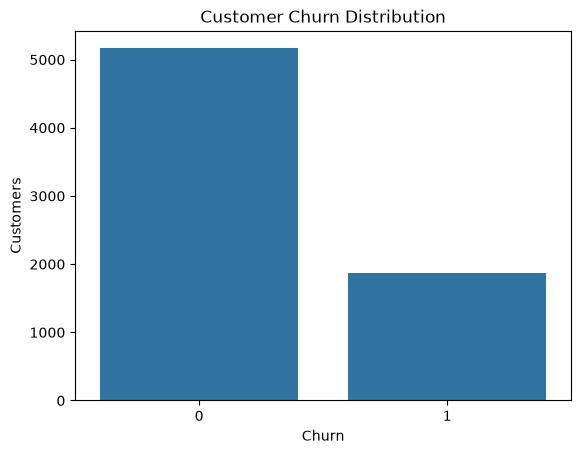

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")

plt.show()

In [4]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

print(churn_percentage)

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [5]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .mean()
    .sort_values(ascending=False)
)

print(contract_churn)

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64


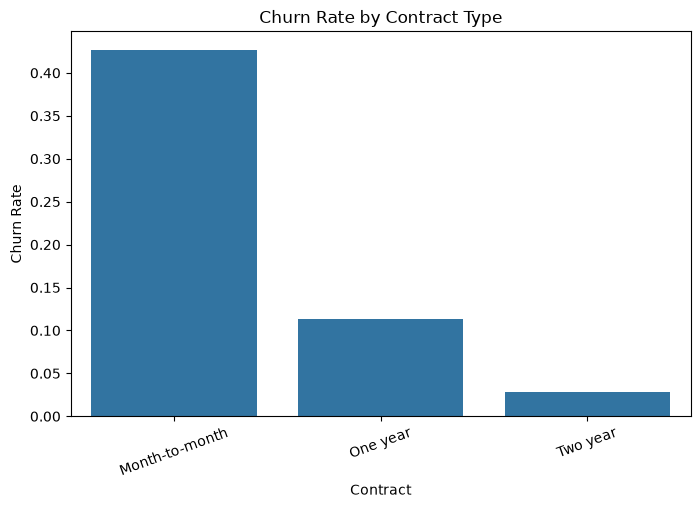

In [6]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract")

plt.xticks(rotation=20)

plt.show()

In [11]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 60, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-60 Months",
        "61-72 Months",
    ],
    include_lowest=True,
)

In [12]:
tenure_churn = (
    df.groupby(
        "TenureGroup",
        observed=True
    )["Churn"]
    .mean()
)

print(tenure_churn)

TenureGroup
0-12 Months     0.476782
13-24 Months    0.287109
25-48 Months    0.203890
49-60 Months    0.144231
61-72 Months    0.066098
Name: Churn, dtype: float64


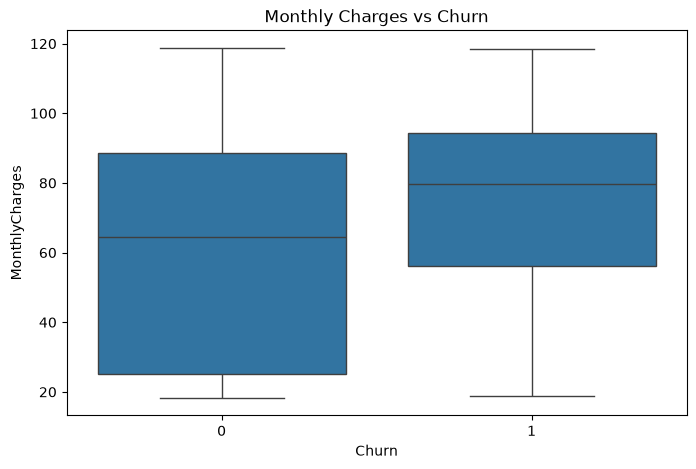

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.show()

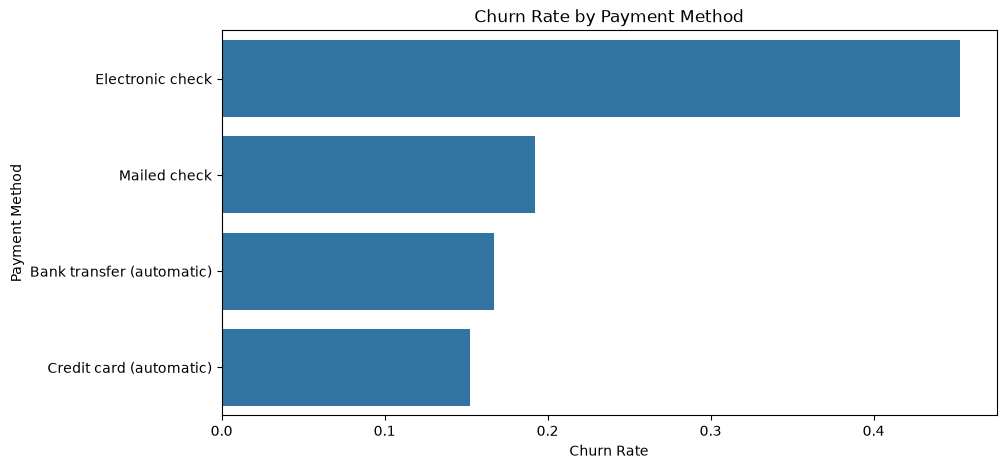

In [14]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_churn.values,
    y=payment_churn.index
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate")
plt.ylabel("Payment Method")

plt.show()